In [2]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import chi2_contingency
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import  cross_val_predict
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import FeatureUnion
from sklearn.impute import MissingIndicator
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import f1_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import os
import glob
import joblib
from sklearn.metrics import confusion_matrix
from optbinning import BinningProcess, Scorecard
from skorch import NeuralNetClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import precision_recall_curve, average_precision_score
from JCC_module import *
from skorch.callbacks import EarlyStopping




#Models of interest
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, roc_auc_score
import joblib
from torch.optim import Adam
from skorch import NeuralNetClassifier

import torch 
import torch.nn as nn


warnings.filterwarnings('ignore')

In [3]:
X_train_fe = pd.read_csv("X_train_fe.csv")
X_val_fe = pd.read_csv("X_val_fe.csv")
X_test_fe = pd.read_csv("X_test_fe.csv")

In [4]:
y_train = pd.read_csv("y_train.csv").squeeze("columns")
y_val = pd.read_csv("y_val.csv").squeeze("columns")
y_test = pd.read_csv("y_test.csv").squeeze("columns")

In [5]:
numerical_col_fe, categorical_col_fe = obtain_col_types(X_train_fe,include_date_columns=False)

preprocessing = ColumnTransformer([
    ("cat", categorical_pipeline, categorical_col_fe),
    ("num", numerical_pipeline, numerical_col_fe)
], remainder="passthrough")

In [6]:
load_and_evaluate_models(model_dir=".",X_val=X_val_fe, y_val=y_val)

F1 optimal threshold for class 0: 0.4444444444444445
Classification report with threshold
              precision    recall  f1-score   support

           0       0.37      0.57      0.45      4822
           1       0.91      0.82      0.86     25178

    accuracy                           0.78     30000
   macro avg       0.64      0.69      0.66     30000
weighted avg       0.82      0.78      0.79     30000

Youden threshold for class 0: 0.2995818555355072
Classification report with Youden threshold
              precision    recall  f1-score   support

           0       0.29      0.80      0.42      4822
           1       0.94      0.63      0.75     25178

    accuracy                           0.65     30000
   macro avg       0.62      0.71      0.59     30000
weighted avg       0.84      0.65      0.70     30000

skipping.\best_smol_model.pkl: 'int' object has no attribute 'predict_proba'
F1 optimal threshold for class 0: 0.4646464646464647
Classification report with thresh

,model_name,roc_auc,optimal f1,optimal youden
0,best_nn_model.pkl,0.790409,0.444444,0.299582
1,best_XGB_sampler_model.pkl,0.752787,0.464646,0.397235
2,lr_l2_weights_model.pkl,0.748405,0.535354,0.495386


In [7]:
final_logistic_name = "lr_l2_weights_model.pkl"
final_tree_name = "best_XGB_sampler_model.pkl"

In [ ]:

#Load saved RandomizedSearchCV object


search = joblib.load("lr_l2_weights_model.pkl")
print("Loaded object type:", type(search))

# Get best fitted pipeline
pipe = search.best_estimator_

print("\nPipeline steps:")
print(pipe.named_steps.keys())

print("\nBest parameters:")
print(search.best_params_)

Loaded object type: <class 'sklearn.model_selection._search.RandomizedSearchCV'>

Pipeline steps:
dict_keys(['preprocess', 'corr_selector', 'tree_selector', 'sampler', 'model'])

Best parameters:
{'sampler': 'passthrough', 'preprocess__num__drop_missing_cols__threshold': 50, 'preprocess__cat__drop_missing_cols__threshold': 90, 'model__tol': 0.001, 'model__solver': 'saga', 'model__penalty': 'l2', 'model__class_weight': {0: 5, 1: 1}, 'model__C': 0.01, 'model': LogisticRegression(max_iter=5000, random_state=42)}


In [ ]:

# Try to manually get feature names after preprocessing

preprocess = pipe.named_steps["preprocess"]

all_feature_names = []
#(name,transformer,columns) from the pipeline
for name, transformer, columns in preprocess.transformers_:

    if transformer == "drop":
        #Theses are the transfromers to skip since they are not class set
        continue

    if transformer == "passthrough":
        #If its passthroguth add each coliumn individualy into the all_feature names
        #different from append because it adds each element seperately
        all_feature_names.extend(columns)
        continue

    #Gets curent column names into a numpy array
    current_names = np.array(columns, dtype=object)

    # If transformer is a pipeline, go step by step
    if isinstance(transformer, Pipeline):

        for step_name, step in transformer.named_steps.items():

            # Custom feature selectors inside preprocessing
            if hasattr(step, "columns_to_drop"):
                current_names = apply_selector_names_safe(
                    current_names, 
                    step, 
                    selector_name=step_name
                )

            # OneHotEncoder
            elif isinstance(step, OneHotEncoder):
                current_names = step.get_feature_names_out(current_names)

            # Imputer with missing indicators
            #find searches fort the case imputer in the step
            #returns the index of the position the imputer is in
            #returns -1 if not anywhere
            elif step_name.lower().find("imputer") != -1:
                #getattr gets searches if the atribute is present and retunrs true if yes and false otherwise
                if hasattr(step, "indicator_") and getattr(step, "add_indicator", False):

                    #gets the column positions where missing idndicators were created
                    indicator_idx = step.indicator_.features_

                    #create the indicator names for the values
                    indicator_names = np.array(
                        [f"{current_names[i]}_missing" for i in indicator_idx],
                        dtype=object
                    )

                    #adds the indicator cretaed names to the original name list
                    #Simply appending to the exisitng variable names
                    current_names = np.concatenate([current_names, indicator_names])

            # Scalers and other transformers do not change names that are imputers
            else:
                pass
            #for methods that have the get feature names out
    else:
        # Non-pipeline transformer
        if hasattr(transformer, "get_feature_names_out"):
            try:
                current_names = transformer.get_feature_names_out(current_names)
            except:
                pass

    #adds the feature names into the list of all names
    all_feature_names.extend(current_names)

#turns into a numpy array 
feature_names = np.array(all_feature_names, dtype=object)

print("\nManual feature names after preprocessing:", len(feature_names))


Manual feature names after preprocessing: 181


In [ ]:

#Check actual preprocessing output size, if X_train_fe exists

try:
    #actually transformes the train onto the transformed variable names 
    X_pre = pipe.named_steps["preprocess"].transform(X_train_fe)
    print("Actual preprocess output columns:", X_pre.shape[1])

    #precautionary steps to see if the manual features calculaetd were actually taken out 
    if len(feature_names) != X_pre.shape[1]:
        print("\nWARNING: Manual feature names do not match actual preprocessing output.")
        print("Manual feature names:", len(feature_names))
        print("Actual preprocess columns:", X_pre.shape[1])
        print("This means exact feature-name recovery may be unreliable.")

except NameError:
    print("\nX_train_fe not found, so actual preprocessing shape could not be checked.")
except Exception as e:
    print("\nCould not check actual preprocessing shape.")
    print("Reason:", e)



Actual preprocess output columns: 181


In [ ]:

# Apply correlation selector safely

if "corr_selector" in pipe.named_steps:
    #it means safely meaning that it keeps tracked of what features were dropped here
    #but then in accordingly updates the list
    corr_selector = pipe.named_steps["corr_selector"]
    feature_names = apply_selector_names_safe(
        feature_names, 
        corr_selector, 
        selector_name="corr_selector"
    )

print("After correlation selector attempt:", len(feature_names))

After correlation selector attempt: 170


In [ ]:

#Apply tree selector safely

if "tree_selector" in pipe.named_steps:
    tree_selector = pipe.named_steps["tree_selector"]
    #tells you which features were kept from the tree selector
    #True and false list
    support_mask = tree_selector.get_support()

    if len(support_mask) == len(feature_names):
        #if the mask has the same length as the feature name list
        #keeps only the features which have true as the output
        feature_names = feature_names[support_mask]
    else:
        print("\nWARNING: tree selector mask does not match feature_names.")
        print("Feature name count:", len(feature_names))
        print("Tree selector mask length:", len(support_mask))
        print("Skipping tree selector for feature names.")

print("After tree selector attempt:", len(feature_names))

After tree selector attempt: 60


In [ ]:

#Match feature names with Logistic Regression coefficients

model = pipe.named_steps["model"]

n_coef = len(model.coef_[0])

print("\nNumber of model coefficients:", n_coef)
print("Number of recovered feature names:", len(feature_names))

# Final safety check
if len(feature_names) != n_coef:
    print("\nWARNING: feature names still do not match coefficients.")
    print("Using generic final feature names instead.")

    feature_names = np.array(
        #gets an arrat of the number of features
        [f"feature_{i}" for i in range(n_coef)],
        dtype=object
    )

#Coefficients dataframe for the logistic regression
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": model.coef_[0]
})

#Gets the absolute value of the coefficiente columns
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

#Sort the values by the coefficient df
coef_df = coef_df.sort_values(
    "abs_coefficient", 
    ascending=False
).reset_index(drop=True)
#drop true means reset index but do not keep the old index

display(coef_df.head(30))

print("\nNumber of final selected features:", len(feature_names))
print("Number of model coefficients:", len(model.coef_[0]))


Number of model coefficients: 60
Number of recovered feature names: 60


,feature,coefficient,abs_coefficient
0,total_rec_prncp,3.316980,3.316980
1,last_fico_range_low,-2.700778,2.700778
2,out_prncp,2.236840,2.236840
3,installment,-1.137291,1.137291
4,int_rate,-0.998211,0.998211
5,verification_status_Verified,-0.524650,0.524650
6,verification_status_Source Verified,-0.263758,0.263758
7,inq_last_6mths,-0.239022,0.239022
8,home_ownership_MORTGAGE,0.196255,0.196255
9,inq_last_12m,-0.191889,0.191889



Number of final selected features: 60
Number of model coefficients: 60


In [ ]:

#OptBinning Scorecard using Top 10 LR Important Variables


# 1. Use top 10 LR features
top_n = 10
#Returns the top 10 features specified by the sorted valyes
top_lr_features = coef_df.head(top_n)["feature"].tolist()

important_raw_features = []


for f in top_lr_features:
    #get raw variable gets the name of the variable after transformations by removing the prefixes and suffixes
    raw_col = get_raw_variable(f, X_train_fe.columns)

    #If the column name is not none and not in the important features then add it
    if raw_col is not None and raw_col not in important_raw_features:
        important_raw_features.append(raw_col)

print("Top 10 LR transformed features:")
print(top_lr_features)

print("\nRaw variables used for scorecard:")
print(important_raw_features)

# 3. Prepare scorecard data
X_train_score = X_train_fe[important_raw_features].copy()
X_val_score = X_val_fe[important_raw_features].copy()
X_test_score = X_test_fe[important_raw_features].copy()

# Original target: 0 = bad/default, 1 = good
# OptBinning scorecard target: 1 = bad/default, 0 = good
#So this creates the 0 case into 1 case for optbinning the target is usually 1
y_train_bad = (y_train == 0).astype(int)
y_val_bad = (y_val == 0).astype(int)
y_test_bad = (y_test == 0).astype(int)

categorical_variables = [
    col for col in important_raw_features
    if X_train_score[col].dtype == "object" or str(X_train_score[col].dtype) == "category"
]

Top 10 LR transformed features:
['total_rec_prncp', 'last_fico_range_low', 'out_prncp', 'installment', 'int_rate', 'verification_status_Verified', 'verification_status_Source Verified', 'inq_last_6mths', 'home_ownership_MORTGAGE', 'inq_last_12m']

Raw variables used for scorecard:
['total_rec_prncp', 'last_fico_range_low', 'out_prncp', 'installment', 'int_rate', 'verification_status', 'inq_last_6mths', 'home_ownership', 'inq_last_12m']


In [15]:
_,categorical_variables = obtain_col_types(X_train_fe,include_date_columns=False)

In [16]:
scorecard = build_scorecard(X_train=X_train_fe,y_train=y_train,feature_list=important_raw_features,categorical_vars=categorical_variables)

In [17]:
#joblib.dump(scorecard, "scorecard.pkl")

In [18]:
scorecard = joblib.load("scorecard.pkl")

In [19]:
display(scorecard.table(style="detailed"))

,Variable,Bin id,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS,Coefficient,Points
0,total_rec_prncp,0,"(-inf, 1996.59)",9208,0.065771,2640,6568,0.713293,-2.564142,0.690755,0.068475,-1.634735,-67.653658
1,total_rec_prncp,1,"[1996.59, 4999.75)",24202,0.172871,16097,8105,0.334890,-0.966559,0.215695,0.025959,-1.634735,7.701853
2,total_rec_prncp,2,"[4999.75, 9999.77)",37792,0.269943,32474,5318,0.140718,0.156631,0.006276,0.000784,-1.634735,60.681042
3,total_rec_prncp,3,"[9999.77, 19998.52)",42907,0.306479,40679,2228,0.051926,1.251896,0.309483,0.036342,-1.634735,112.343026
4,total_rec_prncp,4,"[19998.52, inf)",25891,0.184936,25606,285,0.011008,2.845382,0.584061,0.055388,-1.634735,187.505284
5,total_rec_prncp,5,Special,0,0.000000,0,0,0.000000,0.000000,0.000000,0.000000,-1.634735,53.292985
6,total_rec_prncp,6,Missing,0,0.000000,0,0,0.000000,0.000000,0.000000,0.000000,-1.634735,53.292985
0,last_fico_range_low,0,"(-inf, 572.50)",18141,0.129579,4662,13479,0.743013,-2.714400,1.518115,0.147002,-0.859120,-13.994196
1,last_fico_range_low,1,"[572.50, 647.50)",20702,0.147871,13502,7200,0.347792,-1.023954,0.209940,0.025153,-0.859120,27.910205
2,last_fico_range_low,2,"[647.50, 672.50)",14259,0.101850,13332,927,0.065012,1.013258,0.073233,0.008782,-0.859120,78.410602


In [20]:
#Evaluate the scorecard
val_proba_bad = scorecard.predict_proba(X_val_score)[:, 1]
test_proba_bad = scorecard.predict_proba(X_test_score)[:, 1]

print("\nValidation ROC-AUC:", roc_auc_score(y_val_bad, val_proba_bad))
print("Test ROC-AUC:", roc_auc_score(y_test_bad, test_proba_bad))

threshold = 0.50

val_pred_bad = (val_proba_bad >= threshold).astype(int)
test_pred_bad = (test_proba_bad >= threshold).astype(int)

print("\nValidation Report:")
print(classification_report(y_val_bad, val_pred_bad))

print("\nValidation Confusion Matrix:")
print(confusion_matrix(y_val_bad, val_pred_bad))

print("\nTest Report:")
print(classification_report(y_test_bad, test_pred_bad))

print("\nTest Confusion Matrix:")
print(confusion_matrix(y_test_bad, test_pred_bad))


Validation ROC-AUC: 0.9805193822143122
Test ROC-AUC: 0.9796972907658688

Validation Report:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     25178
           1       0.71      0.93      0.81      4822

    accuracy                           0.93     30000
   macro avg       0.85      0.93      0.88     30000
weighted avg       0.94      0.93      0.93     30000


Validation Confusion Matrix:
[[23380  1798]
 [  324  4498]]

Test Report:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     25177
           1       0.71      0.93      0.81      4823

    accuracy                           0.93     30000
   macro avg       0.85      0.93      0.88     30000
weighted avg       0.94      0.93      0.93     30000


Test Confusion Matrix:
[[23386  1791]
 [  335  4488]]


In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [22]:
net = NeuralNetClassifier(
    module=MLPClassifier_largeNN,
    criterion=torch.nn.CrossEntropyLoss,
    criterion__weight=torch.tensor([3., 1.], dtype=torch.float32),

    optimizer=torch.optim.AdamW,
    optimizer__lr=float(0.0015304852121831463),
    optimizer__weight_decay=float(1.5339162591163613e-05),

    module__dropout=float(0.2529847965068651),

    max_epochs=25,
    batch_size=256,
    iterator_train__shuffle=True,
    verbose=1,
    device=device
)

In [23]:
preprocessing =build_preprocessor(numerical_cols=numerical_col_fe, categorical_cols=categorical_col_fe)

In [24]:
final_nn_pipe = build_nn_pipeline(net,preprocessing=preprocessing)

In [25]:
final_nn_pipe.fit(X_train_fe, y_train)

  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.5444       0.8160        0.5159  6.8150
      2        0.5210       0.7891        0.5093  6.6949
      3        0.5175       0.8086        0.5084  6.4503
      4        0.5154       0.7853        0.5101  6.3853
      5        0.5140       0.8049        0.5082  6.4608
      6        0.5116       0.8013        0.5087  6.4750
      7        0.5118       0.8032        0.5104  7.3863
      8        0.5083       0.7979        0.5089  6.5894
      9        0.5086       0.7933        0.5098  6.3097
     10        0.5070       0.7859        0.5083  6.5934
     11        0.5069       0.7990        0.5102  6.5215
     12        0.5043       0.7993        0.5134  6.5657
     13        0.5030       0.7708        0.5132  6.7372
     14        0.5029       0.7951        0.5115  6.7356
     15        0.5001       0.7890        0.5134  6.5890
     16        0.5004       0.7

,steps,"[('preprocess', ...), ('to_numpy', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [26]:
#joblib.dump(final_nn_pipe, "best_nn_model.pkl")

In [27]:
best_model = joblib.load("best_nn_model.pkl")

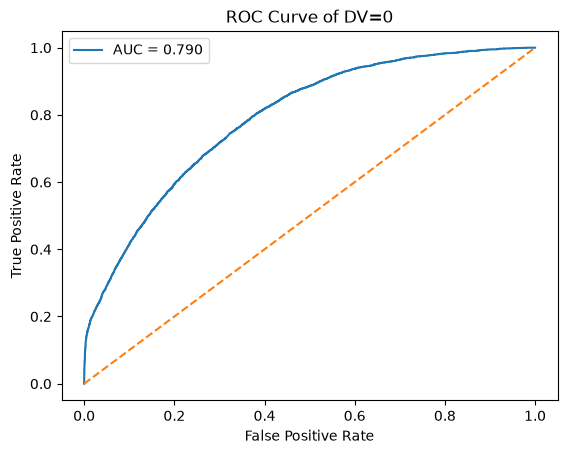

              precision    recall  f1-score   support

           0       0.42      0.46      0.44      4822
           1       0.89      0.88      0.89     25178

    accuracy                           0.81     30000
   macro avg       0.66      0.67      0.66     30000
weighted avg       0.82      0.81      0.81     30000

current model AUC:0.790409
current model name:Best nn model


In [28]:
model_summary(best_model,X_val_fe,y_val,"Best nn model")

In [29]:
Model_evaluator(best_model,X_val=X_val_fe,y_val=y_val,pos_label=0).full_summary()

F1 optimal threshold for class 0: 0.4444444444444445
Classification report with threshold
              precision    recall  f1-score   support

           0       0.37      0.57      0.45      4822
           1       0.91      0.82      0.86     25178

    accuracy                           0.78     30000
   macro avg       0.64      0.69      0.66     30000
weighted avg       0.82      0.78      0.79     30000

Youden threshold for class 0: 0.2995818555355072
Classification report with Youden threshold
              precision    recall  f1-score   support

           0       0.29      0.80      0.42      4822
           1       0.94      0.63      0.75     25178

    accuracy                           0.65     30000
   macro avg       0.62      0.71      0.59     30000
weighted avg       0.84      0.65      0.70     30000


optimal f1 : 0.4444
              precision    recall  f1-score   support

           0       0.37      0.57      0.45      4822
           1       0.91      0.82

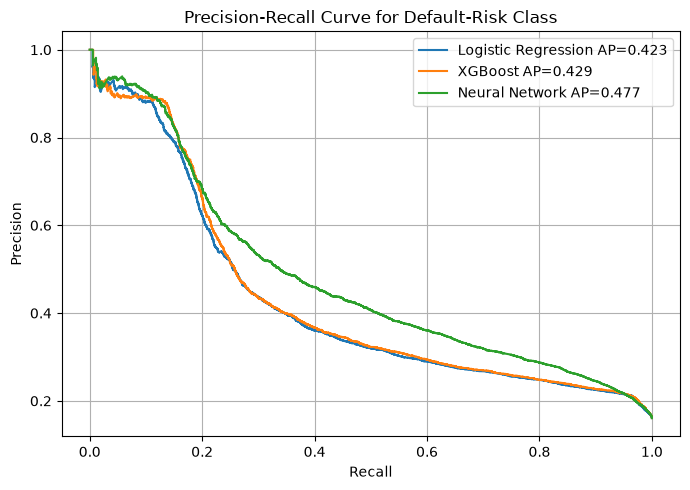

In [30]:
lr_model = joblib.load("lr_l2_weights_model.pkl")
xgb_model = joblib.load("best_XGB_sampler_model.pkl")

plt.figure(figsize=(7, 5))

# Treat class 0 as the positive/default-risk class(class 1)
y_test_class0 = (y_test == 0).astype(int)

# ============================================================
# Logistic Regression and XGBoost
# ============================================================

models = {
    "Logistic Regression": lr_model,
    "XGBoost": xgb_model,
    "Neural Network": best_model
}

for name, model in models.items():

    proba = model.predict_proba(X_test_fe)

    # Get probability of class 0
    class_0_index = list(model.classes_).index(0)
    y_score = proba[:, class_0_index]

    precision, recall, thresholds = precision_recall_curve(
        y_test_class0,
        y_score
    )
    #Calculates the precision and recall of many different thresholds

    #Summarizes the precision and recall curve into 1 number
    ap = average_precision_score(y_test_class0, y_score)

    plt.plot(recall, precision, label=f"{name} AP={ap:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Default-Risk Class")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()